In [1]:
# Run this first in Colab to ensure all libraries are available
!pip install scikit-learn pandas numpy matplotlib seaborn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    roc_curve, classification_report
)

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.dpi'] = 110
print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [2]:
# Upload your CSV file in Colab using the sidebar, or mount Google Drive
# If using Drive:
# from google.colab import drive
# drive.mount('/content/drive')
# df = pd.read_csv('/content/drive/MyDrive/cardio_train.csv', sep=';')

df = pd.read_csv('cardio_train.csv', sep=';')
# NOTE: This dataset uses semicolon (;) as separator, NOT comma
# That's why we pass sep=';'

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (70000, 13)

First 5 rows:


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [3]:
# Understand what we're working with before touching anything

print("=== Column Data Types ===")
print(df.dtypes)

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Basic Statistics ===")
print(df.describe())

print("\n=== Target Column Distribution ===")
print(df['cardio'].value_counts())
print(df['cardio'].value_counts(normalize=True).round(3))

=== Column Data Types ===
id               int64
age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object

=== Missing Values ===
id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

=== Basic Statistics ===
                 id           age        gender        height        weight  \
count  70000.000000  70000.000000  70000.000000  70000.000000  70000.000000   
mean   49972.419900  19468.865814      1.349571    164.359229     74.205690   
std    28851.302323   2467.251667      0.476838      8.210126     14.395757   
min        0.000000  10798.000000      1.000000     55.000000

In [4]:
# WHY: The 'id' column is just a row identifier (1, 2, 3...)
# It carries ZERO medical information.
# If we keep it, the model might accidentally learn patterns from IDs,
# which would be completely meaningless and cause data leakage.

print("Before drop:", df.shape)
df = df.drop(columns=['id'])
print("After drop:", df.shape)
print("Columns remaining:", df.columns.tolist())

Before drop: (70000, 13)
After drop: (70000, 12)
Columns remaining: ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']


In [5]:
# WHY: The 'age' column is stored in DAYS, not years.
# Example: 19722 days = ~54 years
# 
# We convert to years because:
# 1. It's human-interpretable (doctors think in years, not days)
# 2. It makes our EDA plots readable
# 3. The MODEL doesn't care (days or years, the relationship is linear),
#    but WE care for understanding the analysis

df['age_years'] = (df['age'] / 365.25).round(1)

print("Sample age comparison:")
print(df[['age', 'age_years']].head(10))
print(f"\nAge range: {df['age_years'].min()} years to {df['age_years'].max()} years")

Sample age comparison:
     age  age_years
0  18393       50.4
1  20228       55.4
2  18857       51.6
3  17623       48.2
4  17474       47.8
5  21914       60.0
6  22113       60.5
7  22584       61.8
8  17668       48.4
9  19834       54.3

Age range: 29.6 years to 64.9 years


In [6]:
# WHY: Blood pressure columns (ap_hi = systolic, ap_lo = diastolic) have
# CLEARLY WRONG data entries. Look at this:

print("=== Blood Pressure Statistics BEFORE cleaning ===")
print(df[['ap_hi', 'ap_lo']].describe())

print(f"\nRows where ap_hi < 0: {(df['ap_hi'] < 0).sum()}")
print(f"Rows where ap_hi > 300: {(df['ap_hi'] > 300).sum()}")
print(f"Rows where ap_lo < 0: {(df['ap_lo'] < 0).sum()}")
print(f"Rows where systolic <= diastolic: {(df['ap_hi'] <= df['ap_lo']).sum()}")

# These are physically impossible values — clearly data entry errors
# (someone typed 1100 instead of 110, or negative values, etc.)
# 
# MEDICAL RULES we apply:
# - Systolic (ap_hi) must be between 70 and 250 mmHg
#   (Below 70 = fatal shock, Above 250 = hypertensive crisis emergency)
# - Diastolic (ap_lo) must be between 40 and 200 mmHg
# - Systolic MUST always be GREATER than diastolic (basic physiology)

before = len(df)

df = df[(df['ap_hi'] >= 70)  & (df['ap_hi'] <= 250)]
df = df[(df['ap_lo'] >= 40)  & (df['ap_lo'] <= 200)]
df = df[df['ap_hi'] > df['ap_lo']]   # systolic must be > diastolic

after = len(df)
removed = before - after
print(f"\n✅ Removed {removed} rows ({removed/before*100:.2f}% of data)")
print(f"Remaining rows: {after}")

print("\n=== Blood Pressure Statistics AFTER cleaning ===")
print(df[['ap_hi', 'ap_lo']].describe())

=== Blood Pressure Statistics BEFORE cleaning ===
              ap_hi         ap_lo
count  70000.000000  70000.000000
mean     128.817286     96.630414
std      154.011419    188.472530
min     -150.000000    -70.000000
25%      120.000000     80.000000
50%      120.000000     80.000000
75%      140.000000     90.000000
max    16020.000000  11000.000000

Rows where ap_hi < 0: 7
Rows where ap_hi > 300: 40
Rows where ap_lo < 0: 1
Rows where systolic <= diastolic: 1236

✅ Removed 1329 rows (1.90% of data)
Remaining rows: 68671

=== Blood Pressure Statistics AFTER cleaning ===
              ap_hi         ap_lo
count  68671.000000  68671.000000
mean     126.675103     81.307976
std       16.693042      9.453563
min       70.000000     40.000000
25%      120.000000     80.000000
50%      120.000000     80.000000
75%      140.000000     90.000000
max      240.000000    182.000000


In [7]:
# WHY: Same issue — clearly wrong data entries in height and weight.

print("=== Before cleaning ===")
print(df[['height', 'weight']].describe())
print(f"\nHeight < 100cm: {(df['height'] < 100).sum()} rows")
print(f"Height > 220cm: {(df['height'] > 220).sum()} rows")
print(f"Weight < 30kg:  {(df['weight'] < 30).sum()} rows")
print(f"Weight > 200kg: {(df['weight'] > 200).sum()} rows")

# RULES applied:
# - Height: 120–220 cm  (below 120 = data error, not a medical dwarf patient)
# - Weight: 30–200 kg   (below 30 = likely a data entry error at this scale)

before = len(df)

df = df[(df['height'] >= 120) & (df['height'] <= 220)]
df = df[(df['weight'] >= 30)  & (df['weight'] <= 200)]

after = len(df)
print(f"\n✅ Removed {before - after} more rows")
print(f"Final cleaned dataset size: {after} rows")

print("\n=== After cleaning ===")
print(df[['height', 'weight']].describe())

=== Before cleaning ===
             height        weight
count  68671.000000  68671.000000
mean     164.360968     74.118136
std        8.183668     14.331593
min       55.000000     11.000000
25%      159.000000     65.000000
50%      165.000000     72.000000
75%      170.000000     82.000000
max      250.000000    200.000000

Height < 100cm: 26 rows
Height > 220cm: 1 rows
Weight < 30kg:  6 rows
Weight > 200kg: 0 rows

✅ Removed 56 more rows
Final cleaned dataset size: 68615 rows

=== After cleaning ===
             height        weight
count  68615.000000  68615.000000
mean     164.413277     74.114930
std        7.912669     14.295824
min      120.000000     30.000000
25%      159.000000     65.000000
50%      165.000000     72.000000
75%      170.000000     82.000000
max      207.000000    200.000000


In [8]:
# WHY: We CREATE new columns from existing ones that may be more informative.
# This is called "Feature Engineering".

# ── BMI (Body Mass Index) ──────────────────────────────────────────────────
# WHY: BMI combines height AND weight into a single medically-standard obesity measure.
# The model can learn more from BMI than from height and weight separately,
# because it captures their INTERACTION (a 100kg person at 190cm is fine;
# at 150cm that's dangerously obese).
#
# Formula: BMI = weight(kg) / height(m)²

df['bmi'] = (df['weight'] / ((df['height'] / 100) ** 2)).round(1)

# ── Pulse Pressure ────────────────────────────────────────────────────────
# WHY: Pulse pressure = systolic - diastolic
# High pulse pressure is an INDEPENDENT risk factor for cardiovascular disease
# in clinical medicine — it captures arterial stiffness, which systolic or
# diastolic alone do not.

df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']

# ── BMI Category (for EDA only, not model input) ─────────────────────────
def bmi_category(bmi):
    if bmi < 18.5: return 'Underweight'
    elif bmi < 25: return 'Normal'
    elif bmi < 30: return 'Overweight'
    else: return 'Obese'

df['bmi_category'] = df['bmi'].apply(bmi_category)

# ── Age Group (for EDA only) ──────────────────────────────────────────────
def age_group(age):
    if age < 40:   return '<40'
    elif age < 50: return '40-49'
    elif age < 60: return '50-59'
    else:          return '60+'

df['age_group'] = df['age_years'].apply(age_group)

# ── Readable Labels (for EDA only) ───────────────────────────────────────
df['gender_label']      = df['gender'].map({1: 'Women', 2: 'Men'})
df['cholesterol_label'] = df['cholesterol'].map({1:'Normal', 2:'Above Normal', 3:'Well Above Normal'})
df['gluc_label']        = df['gluc'].map({1:'Normal', 2:'Above Normal', 3:'Well Above Normal'})

print("New columns created:")
print(df[['bmi', 'pulse_pressure', 'bmi_category', 'age_group']].head(10))
print(f"\nDataset shape after feature engineering: {df.shape}")

New columns created:
    bmi  pulse_pressure bmi_category age_group
0  22.0              30       Normal     50-59
1  34.9              50        Obese     50-59
2  23.5              60       Normal     50-59
3  28.7              50   Overweight     40-49
4  23.0              40       Normal     40-49
5  29.4              40   Overweight       60+
6  37.7              50        Obese       60+
7  30.0              40        Obese       60+
8  28.4              40   Overweight     40-49
9  25.3              50   Overweight     50-59

Dataset shape after feature engineering: (68615, 20)


In [9]:
# Final check before moving to visualization

print("=" * 50)
print("PREPROCESSING SUMMARY")
print("=" * 50)
print(f"Original rows:        70,000")
print(f"Rows after cleaning:  {len(df)}")
print(f"Rows removed:         {70000 - len(df)} ({(70000 - len(df))/70000*100:.2f}%)")
print(f"\nMissing values remaining: {df.isnull().sum().sum()}")
print(f"\nTarget class balance:")
print(df['cardio'].value_counts())
print(f"\nColumns in final dataset:")
for col in df.columns:
    print(f"  • {col}")

df.to_csv('cardio_clean.csv', index=False)
print("\n✅ Clean dataset saved as cardio_clean.csv")

PREPROCESSING SUMMARY
Original rows:        70,000
Rows after cleaning:  68615
Rows removed:         1385 (1.98%)

Missing values remaining: 0

Target class balance:
cardio
0    34670
1    33945
Name: count, dtype: int64

Columns in final dataset:
  • age
  • gender
  • height
  • weight
  • ap_hi
  • ap_lo
  • cholesterol
  • gluc
  • smoke
  • alco
  • active
  • cardio
  • age_years
  • bmi
  • pulse_pressure
  • bmi_category
  • age_group
  • gender_label
  • cholesterol_label
  • gluc_label

✅ Clean dataset saved as cardio_clean.csv


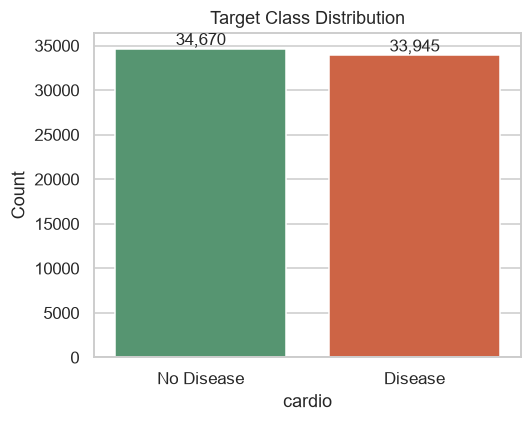

In [10]:
plt.figure(figsize=(5, 4))
ax = sns.countplot(x='cardio', data=df, hue='cardio',
                   palette=['#4C9F70', '#E4572E'], legend=False)
ax.set_xticks([0, 1])
ax.set_xticklabels(['No Disease', 'Disease'])
plt.title('Target Class Distribution')
plt.ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()
# INSIGHT: Near 50-50 split — no class imbalance problem.

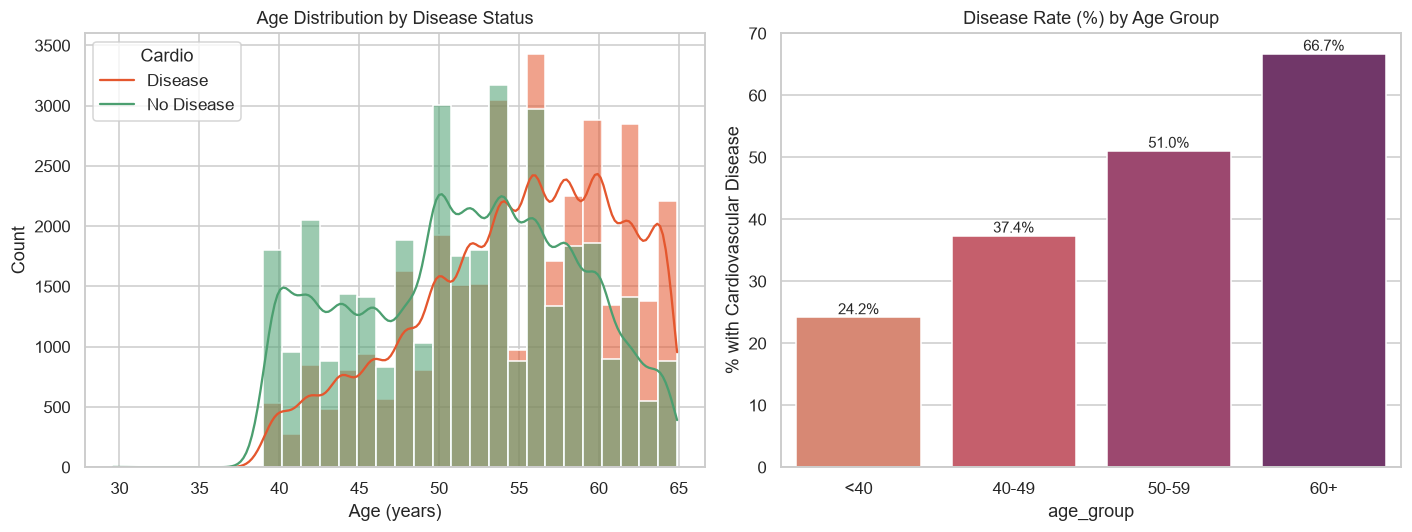

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Age histogram by disease status
sns.histplot(data=df, x='age_years', hue='cardio', bins=30,
             kde=True, palette=['#4C9F70', '#E4572E'],
             multiple='layer', alpha=0.55, ax=axes[0])
axes[0].set_title('Age Distribution by Disease Status')
axes[0].set_xlabel('Age (years)')
axes[0].legend(title='Cardio', labels=['Disease', 'No Disease'])

# Disease rate by age group
order = ['<40', '40-49', '50-59', '60+']
rate = df.groupby('age_group')['cardio'].mean().reindex(order) * 100
sns.barplot(x=rate.index, y=rate.values, hue=rate.index,
            palette='flare', legend=False, ax=axes[1])
axes[1].set_title('Disease Rate (%) by Age Group')
axes[1].set_ylabel('% with Cardiovascular Disease')
for i, v in enumerate(rate.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()
# INSIGHT: Disease rate nearly DOUBLES from <40 group to 60+ group

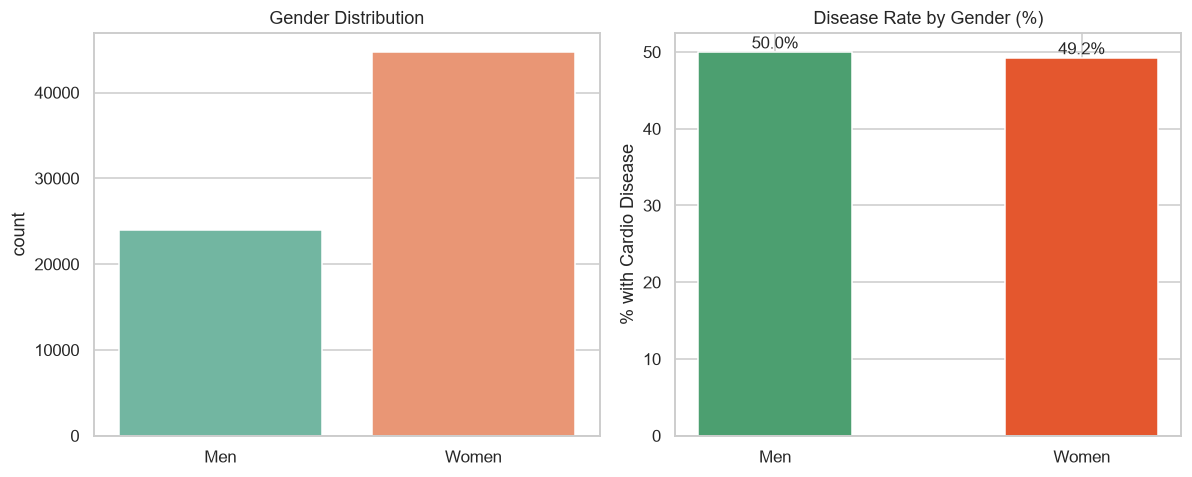

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

sns.countplot(x='gender_label', data=df, hue='gender_label',
              palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Gender Distribution')
axes[0].set_xlabel('')

rate = df.groupby('gender_label')['cardio'].mean() * 100
axes[1].bar(rate.index, rate.values, color=['#4C9F70', '#E4572E'], width=0.5)
axes[1].set_title('Disease Rate by Gender (%)')
axes[1].set_ylabel('% with Cardio Disease')
for i, v in enumerate(rate.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=11)

plt.tight_layout()
plt.show()
# INSIGHT: Gender alone is a weak predictor — rates are close (confirmed later in correlation matrix)

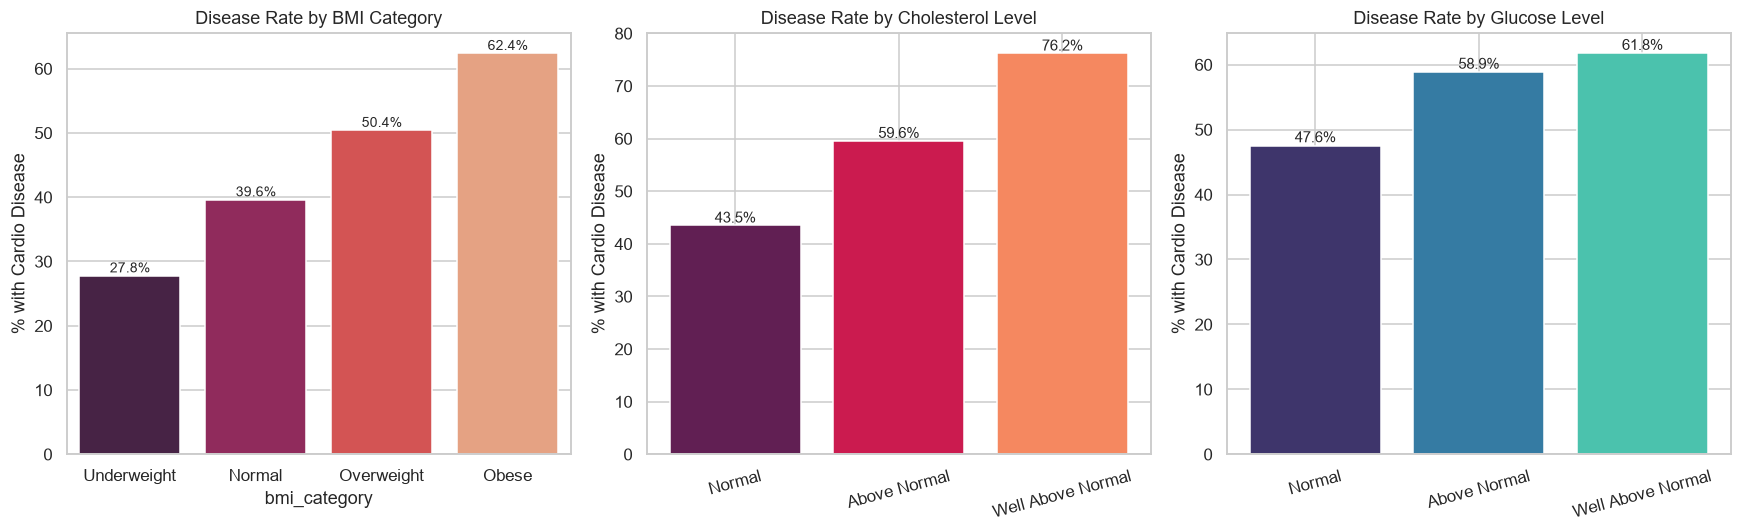

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# BMI Category
bmi_order = ['Underweight', 'Normal', 'Overweight', 'Obese']
rate_bmi = df.groupby('bmi_category')['cardio'].mean().reindex(bmi_order) * 100
sns.barplot(x=rate_bmi.index, y=rate_bmi.values, hue=rate_bmi.index,
            palette='rocket', legend=False, ax=axes[0])
axes[0].set_title('Disease Rate by BMI Category')
axes[0].set_ylabel('% with Cardio Disease')
for i, v in enumerate(rate_bmi.values):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)

# Cholesterol
chol_order = ['Normal', 'Above Normal', 'Well Above Normal']
rate_c = df.groupby('cholesterol_label')['cardio'].mean().reindex(chol_order) * 100
axes[1].bar(chol_order, rate_c.values, color=sns.color_palette('rocket', 3))
axes[1].set_title('Disease Rate by Cholesterol Level')
axes[1].set_ylabel('% with Cardio Disease')
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(rate_c.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10)

# Glucose
rate_g = df.groupby('gluc_label')['cardio'].mean().reindex(chol_order) * 100
axes[2].bar(chol_order, rate_g.values, color=sns.color_palette('mako', 3))
axes[2].set_title('Disease Rate by Glucose Level')
axes[2].set_ylabel('% with Cardio Disease')
axes[2].tick_params(axis='x', rotation=15)
for i, v in enumerate(rate_g.values):
    axes[2].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

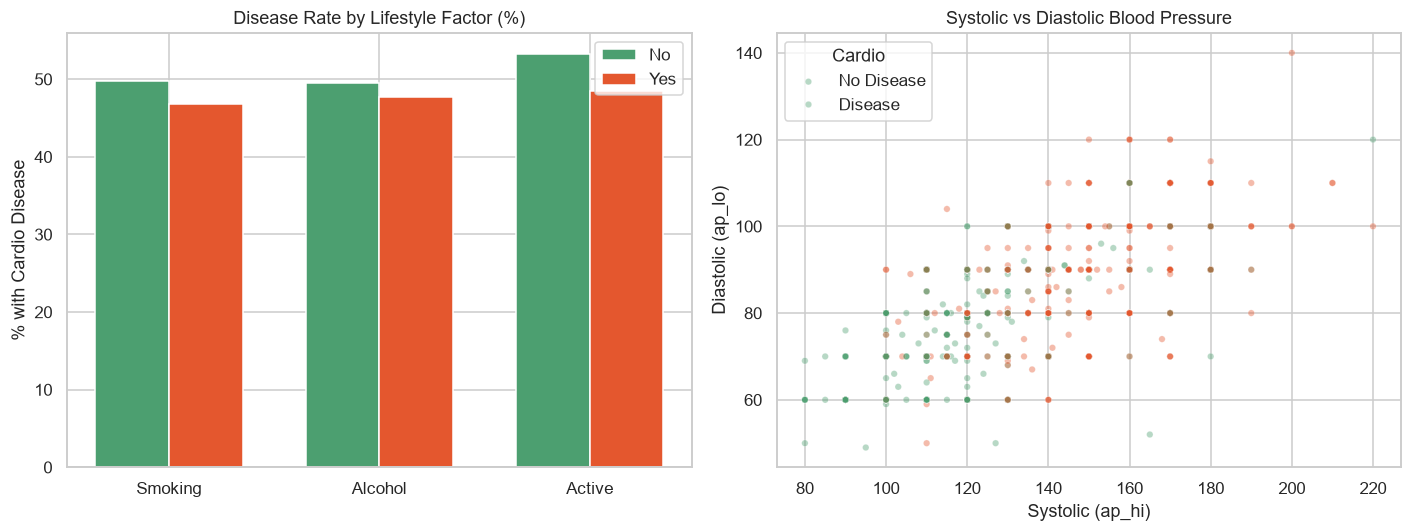

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Lifestyle factors
ax = axes[0]
lifestyle = {}
for col, label in [('smoke','Smoking'), ('alco','Alcohol'), ('active','Active')]:
    lifestyle[label] = df.groupby(col)['cardio'].mean() * 100

x = np.arange(3)
labels = list(lifestyle.keys())
no_vals  = [lifestyle[l].iloc[0] for l in labels]
yes_vals = [lifestyle[l].iloc[1] for l in labels]
w = 0.35
ax.bar(x - w/2, no_vals,  w, label='No',  color='#4C9F70')
ax.bar(x + w/2, yes_vals, w, label='Yes', color='#E4572E')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_title('Disease Rate by Lifestyle Factor (%)')
ax.set_ylabel('% with Cardio Disease')
ax.legend()

# Blood pressure scatter
sample = df.sample(5000, random_state=42)
sns.scatterplot(data=sample, x='ap_hi', y='ap_lo', hue='cardio',
                palette=['#4C9F70', '#E4572E'], alpha=0.4, s=18, ax=axes[1])
axes[1].set_title('Systolic vs Diastolic Blood Pressure')
axes[1].set_xlabel('Systolic (ap_hi)'); axes[1].set_ylabel('Diastolic (ap_lo)')
axes[1].legend(title='Cardio', labels=['No Disease', 'Disease'])

plt.tight_layout()
plt.show()

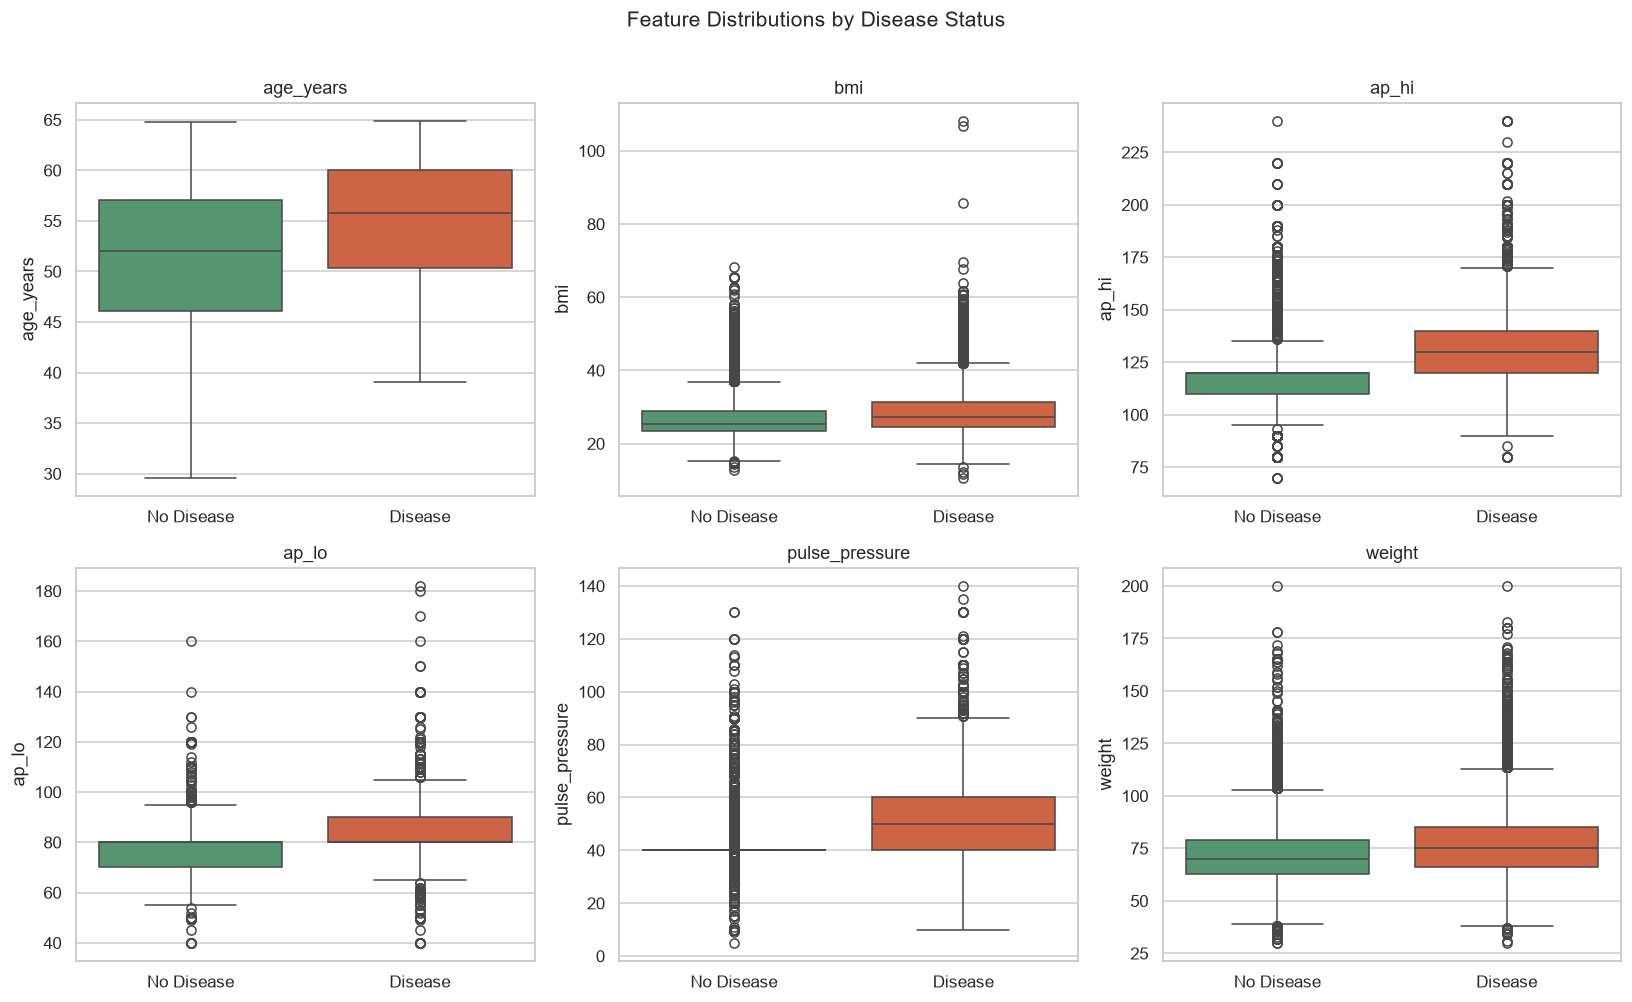

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
features = ['age_years', 'bmi', 'ap_hi', 'ap_lo', 'pulse_pressure', 'weight']

for ax, col in zip(axes.flat, features):
    sns.boxplot(data=df, x='cardio', y=col, hue='cardio',
                palette=['#4C9F70', '#E4572E'], legend=False, ax=ax)
    ax.set_xticks([0, 1]); ax.set_xticklabels(['No Disease', 'Disease'])
    ax.set_title(col); ax.set_xlabel('')

plt.suptitle('Feature Distributions by Disease Status', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()
# INSIGHT: ap_hi (systolic BP) shows the CLEAREST separation between classes

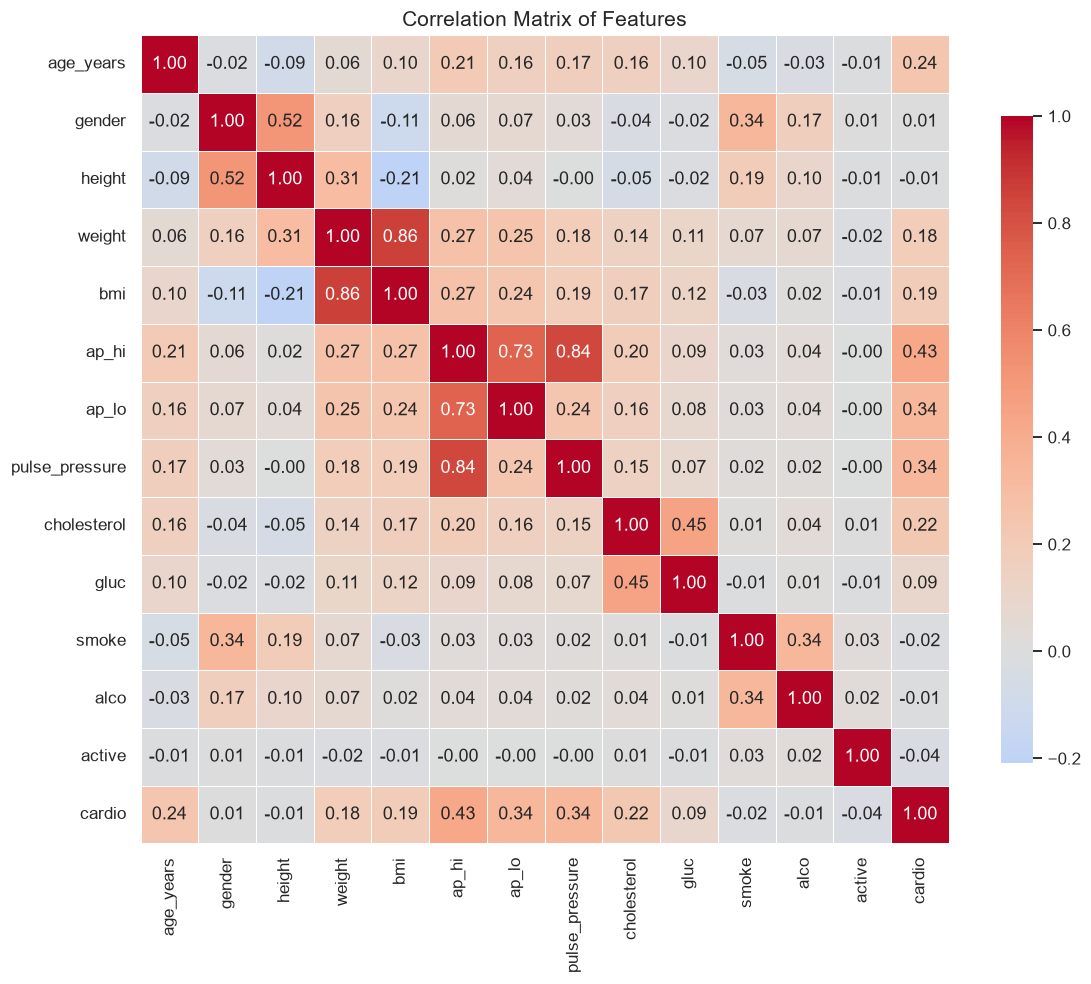


📊 Correlation with Target (cardio) — sorted:
cardio            1.000000
ap_hi             0.428081
ap_lo             0.340182
pulse_pressure    0.336859
age_years         0.239409
cholesterol       0.221421
bmi               0.189597
weight            0.180123
gluc              0.089711
gender            0.007180
alco             -0.008581
height           -0.011846
smoke            -0.016374
active           -0.037643


In [16]:
# WHY: Correlation matrix shows:
# 1. Which features are most linearly related to the TARGET (cardio)
# 2. Which features are highly correlated WITH EACH OTHER (redundant info)

corr_cols = ['age_years', 'gender', 'height', 'weight', 'bmi',
             'ap_hi', 'ap_lo', 'pulse_pressure',
             'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']

corr = df[corr_cols].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix of Features', fontsize=14)
plt.tight_layout()
plt.show()

# Print sorted correlation with target
print("\n📊 Correlation with Target (cardio) — sorted:")
print(corr['cardio'].sort_values(ascending=False).to_string())

In [17]:
# Select feature columns for the model
# We use the original + engineered medical features
# We do NOT use label/category columns — those are derived from the same data
# and would cause redundancy

feature_cols = [
    'age_years',      # age in years
    'gender',         # 1=women, 2=men
    'height',         # in cm
    'weight',         # in kg
    'bmi',            # derived: weight/height²
    'ap_hi',          # systolic blood pressure
    'ap_lo',          # diastolic blood pressure
    'pulse_pressure', # derived: systolic - diastolic
    'cholesterol',    # 1/2/3 categorical
    'gluc',           # 1/2/3 categorical
    'smoke',          # 0/1 binary
    'alco',           # 0/1 binary
    'active'          # 0/1 binary
]

X = df[feature_cols].copy()
y = df['cardio'].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")

Feature matrix shape: (68615, 13)
Target shape: (68615,)

Feature columns:
   1. age_years
   2. gender
   3. height
   4. weight
   5. bmi
   6. ap_hi
   7. ap_lo
   8. pulse_pressure
   9. cholesterol
  10. gluc
  11. smoke
  12. alco
  13. active


In [18]:
# WHY 80/20 split:
# - 80% for training → more data = better model
# - 20% for testing  → enough to evaluate reliably
# 
# stratify=y ensures BOTH train and test have the same ~50/50 class balance
# (without this, by random chance one split might get 60% disease patients)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,   # makes the split reproducible
    stratify=y         # preserves class balance
)

print(f"Training set:  {X_train.shape[0]:,} rows")
print(f"Test set:      {X_test.shape[0]:,} rows")
print(f"\nClass distribution in training set:")
print(y_train.value_counts(normalize=True).round(3))
print(f"\nClass distribution in test set:")
print(y_test.value_counts(normalize=True).round(3))

Training set:  54,892 rows
Test set:      13,723 rows

Class distribution in training set:
cardio
0    0.505
1    0.495
Name: proportion, dtype: float64

Class distribution in test set:
cardio
0    0.505
1    0.495
Name: proportion, dtype: float64


In [19]:
# WHY StandardScaler:
# Many ML algorithms (especially SVM, KNN, Logistic Regression) are sensitive
# to the SCALE of features.
# 
# Example problem WITHOUT scaling:
#   ap_hi ranges 70–250  (large numbers)
#   smoke  ranges 0–1    (tiny numbers)
# KNN would almost entirely ignore 'smoke' because the Euclidean distance is
# dominated by ap_hi.
#
# StandardScaler transforms each feature to mean=0, std=1
# Formula: z = (x - mean) / std
#
# IMPORTANT: Fit ONLY on training data, then apply to both.
# WHY: If we fit on all data including test, test data "leaks" its mean/std
# into training — this is data leakage and gives artificially good results.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train, transform train
X_test_scaled  = scaler.transform(X_test)         # only transform test (no fit!)

print("Scaling applied ✅")
print(f"Before scaling — ap_hi mean: {X_train['ap_hi'].mean():.2f}, std: {X_train['ap_hi'].std():.2f}")
print(f"After scaling  — ap_hi mean: {X_train_scaled[:,5].mean():.4f}, std: {X_train_scaled[:,5].std():.4f}")

Scaling applied ✅
Before scaling — ap_hi mean: 126.57, std: 16.67
After scaling  — ap_hi mean: -0.0000, std: 1.0000


In [20]:
import time

# Define all 5 models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN':                 KNeighborsClassifier(n_neighbors=15),
    'Decision Tree':       DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=10,
                                                   random_state=42, n_jobs=-1),
    'SVM (RBF)':           SVC(kernel='rbf', probability=True, random_state=42)
}

# SVM is slow on 55k rows — we use a subsample for it
# (8000 rows is enough to get a good estimate of its accuracy)
SVM_SAMPLE = 8000
rng = np.random.RandomState(42)
idx = rng.choice(len(X_train_scaled), size=SVM_SAMPLE, replace=False)
X_train_svm = X_train_scaled[idx]
y_train_svm = y_train.values[idx]

results = []

for name, model in models.items():
    t0 = time.time()

    # Train
    if name == 'SVM (RBF)':
        model.fit(X_train_svm, y_train_svm)
    else:
        model.fit(X_train_scaled, y_train)

    elapsed = time.time() - t0

    # Predict
    y_pred  = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    # Metrics
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_proba)

    results.append({
        'Model': name,
        'Accuracy':  round(acc * 100, 2),
        'Precision': round(prec * 100, 2),
        'Recall':    round(rec * 100, 2),
        'F1-Score':  round(f1 * 100, 2),
        'ROC-AUC':   round(auc, 4),
        'Time (s)':  round(elapsed, 2)
    })

    print(f"✅ {name} trained in {elapsed:.1f}s — Accuracy: {acc*100:.2f}%")

print("\n✅ All models trained!")

✅ Logistic Regression trained in 0.2s — Accuracy: 72.86%
✅ KNN trained in 0.5s — Accuracy: 72.19%
✅ Decision Tree trained in 0.2s — Accuracy: 73.07%
✅ Random Forest trained in 7.6s — Accuracy: 73.53%


c:\Users\Administrator\Desktop\ds_projects\venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


✅ SVM (RBF) trained in 41.7s — Accuracy: 73.26%

✅ All models trained!


In [21]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [6, 8, 10, 12],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1
)
grid.fit(X_train_scaled, y_train)

print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)

rf_final = grid.best_estimator_  # use this in place of the hardcoded version

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 150}
Best CV score: 0.7324382375429915


In [22]:
results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False).reset_index(drop=True)

print("=" * 75)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 75)
print(results_df.to_string(index=False))

MODEL PERFORMANCE COMPARISON
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC  Time (s)
      Random Forest     73.53      75.97   68.02     71.77   0.8043      7.63
          SVM (RBF)     73.26      76.00   67.17     71.31   0.7916     41.67
      Decision Tree     73.07      76.55   65.68     70.70   0.7963      0.17
Logistic Regression     72.86      75.04   67.64     71.15   0.7955      0.19
                KNN     72.19      73.05   69.36     71.16   0.7827      0.48


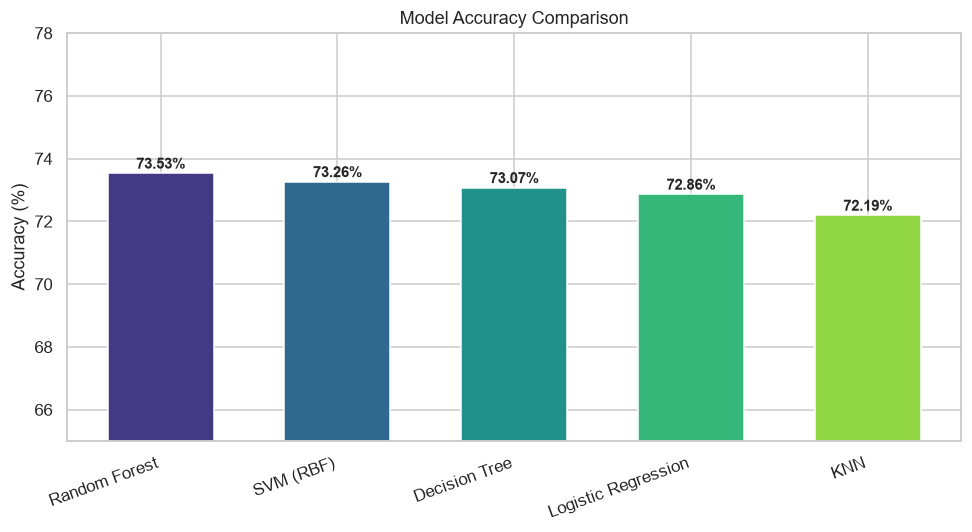

In [23]:
plt.figure(figsize=(9, 5))
colors = sns.color_palette('viridis', len(results_df))
bars = plt.bar(results_df['Model'], results_df['Accuracy'], color=colors, width=0.6)
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy Comparison')
plt.xticks(rotation=20, ha='right')
plt.ylim(65, 78)

for bar, val in zip(bars, results_df['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.15,
             f'{val:.2f}%', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

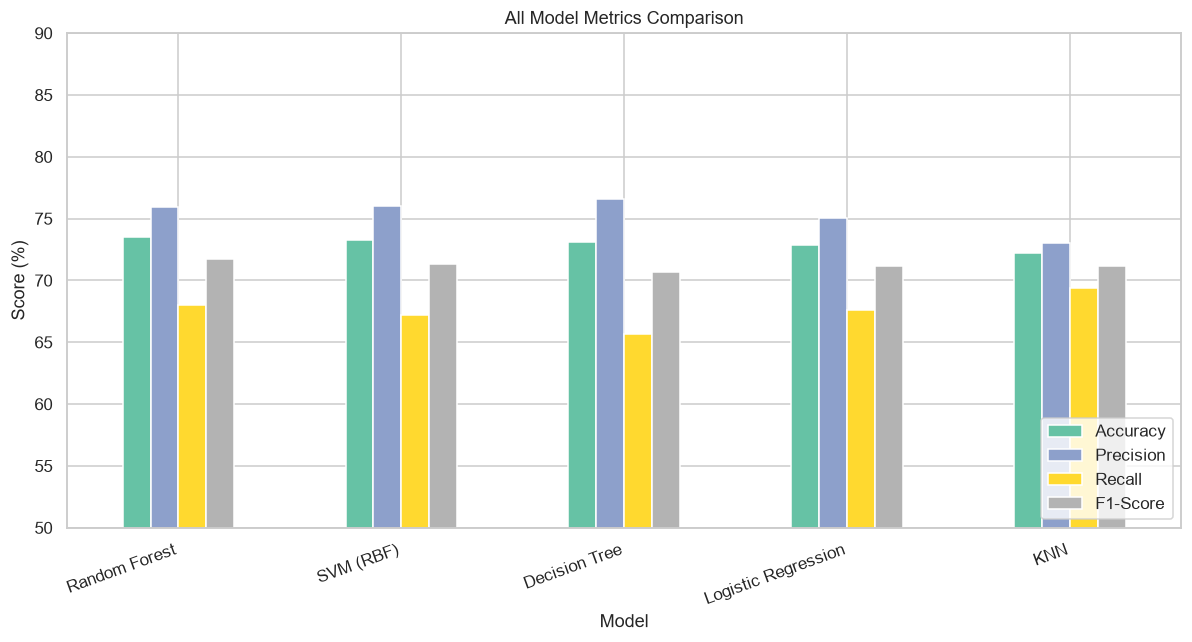

In [24]:
metrics_df = results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score']]

metrics_df.plot(kind='bar', figsize=(11, 6), colormap='Set2')
plt.ylabel('Score (%)')
plt.title('All Model Metrics Comparison')
plt.xticks(rotation=20, ha='right')
plt.ylim(50, 90)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

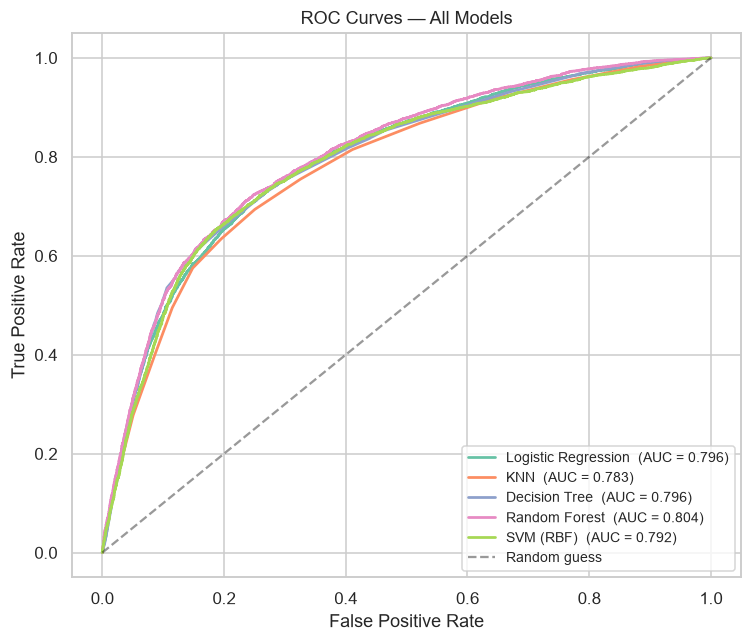

In [25]:
plt.figure(figsize=(7, 6))

for name, model in models.items():
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name}  (AUC = {auc:.3f})', linewidth=1.8)

plt.plot([0,1],[0,1],'k--', alpha=0.4, label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

# AUC > 0.5 means the model is better than random
# AUC = 1.0 would be a perfect model

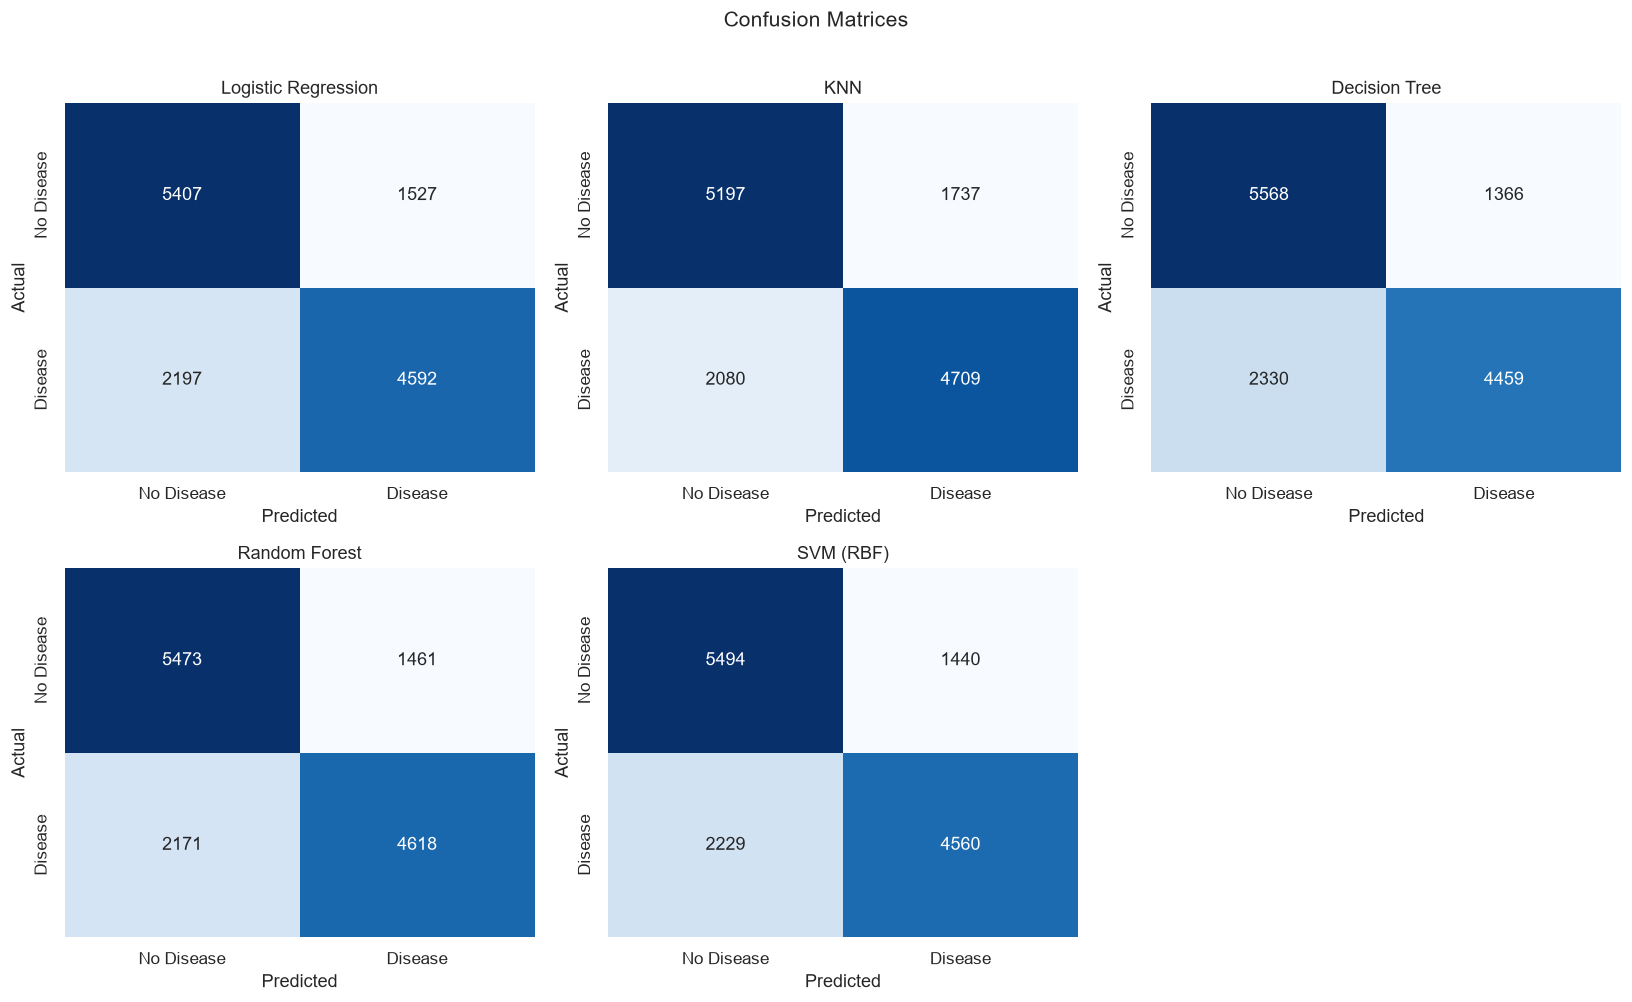

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, (name, model) in zip(axes.flat, models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

axes.flat[-1].axis('off')
plt.suptitle('Confusion Matrices', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# How to read a confusion matrix:
# Top-left:  True Negatives  (correctly said "No Disease")
# Top-right: False Positives (wrongly said "Disease")
# Bot-left:  False Negatives (wrongly said "No Disease") ← most dangerous in medical context
# Bot-right: True Positives  (correctly said "Disease")

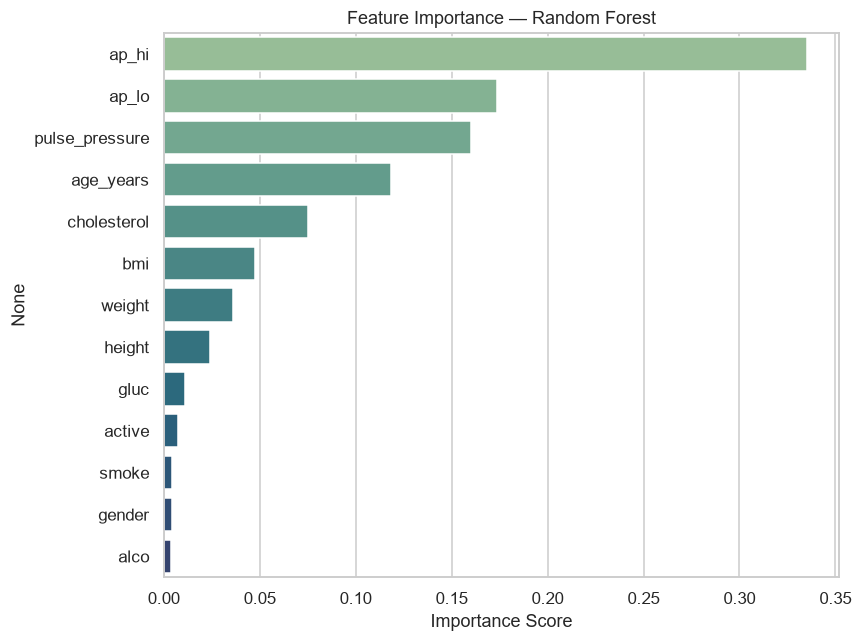


📊 Feature Importance Rankings:
  ap_hi                 0.3352  ███████████████████████████████████████████████████████████████████
  ap_lo                 0.1734  ██████████████████████████████████
  pulse_pressure        0.1602  ████████████████████████████████
  age_years             0.1182  ███████████████████████
  cholesterol           0.0751  ███████████████
  bmi                   0.0473  █████████
  weight                0.0359  ███████
  height                0.0238  ████
  gluc                  0.0112  ██
  active                0.0074  █
  smoke                 0.0045  
  gender                0.0042  
  alco                  0.0035  


In [27]:
rf_model = models['Random Forest']

importances = pd.Series(rf_model.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index,
            hue=importances.index, palette='crest', legend=False)
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\n📊 Feature Importance Rankings:")
for feat, imp in importances.items():
    bar = '█' * int(imp * 200)
    print(f"  {feat:<20}  {imp:.4f}  {bar}")

5-FOLD CROSS VALIDATION — Random Forest
  Fold 1: 73.29%
  Fold 2: 73.27%
  Fold 3: 73.06%
  Fold 4: 72.83%
  Fold 5: 73.40%

  Mean:  73.17%
  Std:   0.20%

✅ Stable performance — model is NOT overfitting


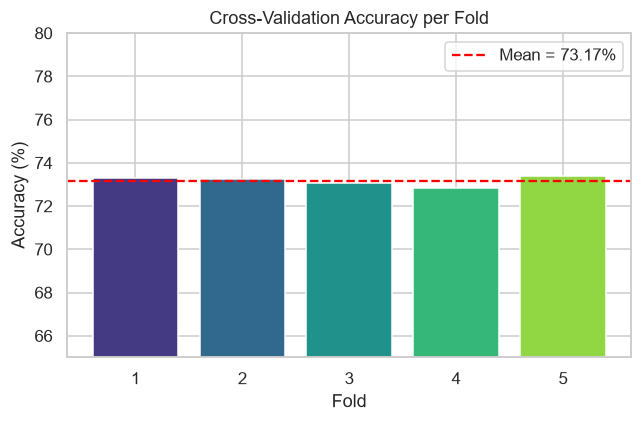

In [28]:
# WHY Cross-Validation?
# A single train/test split can be lucky or unlucky depending on
# which rows ended up in which set.
# 
# 5-fold CV: Split training data into 5 parts.
# Train on 4 parts, test on 1. Rotate which part is the test. Repeat 5 times.
# Average the 5 accuracy scores → more reliable estimate.

rf_final = RandomForestClassifier(n_estimators=200, max_depth=10,
                                   random_state=42, n_jobs=-1)
cv_scores = cross_val_score(rf_final, X_train_scaled, y_train,
                             cv=5, scoring='accuracy', n_jobs=-1)

print("=" * 45)
print("5-FOLD CROSS VALIDATION — Random Forest")
print("=" * 45)
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score*100:.2f}%")
print(f"\n  Mean:  {cv_scores.mean()*100:.2f}%")
print(f"  Std:   {cv_scores.std()*100:.2f}%")
print(f"\n✅ Stable performance — model is NOT overfitting")

plt.figure(figsize=(6, 4))
plt.bar(range(1, 6), cv_scores * 100, color=sns.color_palette('viridis', 5))
plt.axhline(cv_scores.mean() * 100, color='red', linestyle='--',
            label=f'Mean = {cv_scores.mean()*100:.2f}%')
plt.xlabel('Fold'); plt.ylabel('Accuracy (%)')
plt.title('Cross-Validation Accuracy per Fold')
plt.ylim(65, 80)
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
# Train the final Random Forest on full training set
rf_final.fit(X_train_scaled, y_train)
y_pred_final = rf_final.predict(X_test_scaled)

print("=" * 50)
print("FINAL MODEL REPORT — Random Forest")
print("=" * 50)
print(classification_report(y_test, y_pred_final,
                             target_names=['No Disease', 'Disease']))

print(f"✅ Final Accuracy:  {accuracy_score(y_test, y_pred_final)*100:.2f}%")
print(f"✅ Final ROC-AUC:   {roc_auc_score(y_test, rf_final.predict_proba(X_test_scaled)[:,1]):.4f}")

FINAL MODEL REPORT — Random Forest
              precision    recall  f1-score   support

  No Disease       0.72      0.79      0.75      6934
     Disease       0.76      0.68      0.72      6789

    accuracy                           0.74     13723
   macro avg       0.74      0.73      0.73     13723
weighted avg       0.74      0.74      0.73     13723

✅ Final Accuracy:  73.53%
✅ Final ROC-AUC:   0.8043


In [30]:
# How to use the trained model on a new patient

def predict_patient(age_years, gender, height_cm, weight_kg,
                    ap_hi, ap_lo, cholesterol, gluc, smoke, alco, active):
    bmi = round(weight_kg / (height_cm / 100) ** 2, 1)
    pulse_pressure = ap_hi - ap_lo

    patient = pd.DataFrame([[age_years, gender, height_cm, weight_kg, bmi,
                              ap_hi, ap_lo, pulse_pressure,
                              cholesterol, gluc, smoke, alco, active]],
                            columns=feature_cols)

    patient_scaled = scaler.transform(patient)
    prediction = rf_final.predict(patient_scaled)[0]
    probability = rf_final.predict_proba(patient_scaled)[0]

    print("=" * 45)
    print("CARDIOVASCULAR DISEASE PREDICTION")
    print("=" * 45)
    print(f"  BMI (calculated):    {bmi}")
    print(f"  Pulse Pressure:      {pulse_pressure} mmHg")
    print(f"  Prediction:          {'⚠️  DISEASE DETECTED' if prediction == 1 else '✅  No Disease Detected'}")
    print(f"  Probability — No Disease: {probability[0]*100:.1f}%")
    print(f"  Probability — Disease:    {probability[1]*100:.1f}%")

# Example patient: 55-year-old woman, overweight, high BP
predict_patient(
    age_years=55, gender=1, height_cm=162, weight_kg=85,
    ap_hi=150, ap_lo=95,
    cholesterol=2, gluc=1,
    smoke=0, alco=0, active=1
)

CARDIOVASCULAR DISEASE PREDICTION
  BMI (calculated):    32.4
  Pulse Pressure:      55 mmHg
  Prediction:          ⚠️  DISEASE DETECTED
  Probability — No Disease: 15.4%
  Probability — Disease:    84.6%
